# Iterate over Test Images and calculate Top N (50) machtches of the Prototypes

## Setup (Imports and Preparations)

In [1]:
import os

from albumentations import (
    Compose as ACompose,
    HorizontalFlip as AHorizontalFlip,
    VerticalFlip as AVerticalFlip
)

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

# Custom Library
import ActivationPrototypes_SARSeg.thesis_utils as utils
from ActivationPrototypes_SARSeg.thesis_utils import *

2025-05-04 15:07:18.543 | INFO     | ActivationPrototypes_SARSeg.config:<module>:11 - PROJ_ROOT path is: F:\Thesis\ActivationPrototypes_SARSeg
f:\Thesis\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_lmdb_path = '../data/Encoded-BigEarthNet'
parquet_path = '../data/metadata.parquet'
prototype_lmdb_path = "../data/prototypes_subsample"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

seed=24   # Fix the seed for reproducibility
batch_size= 16
NUM_CLASSES = 20 # 19 classes + 1 unlabeled
n_classes = num_class = NUM_CLASSES

IMG_SIZE = (120,120)
IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

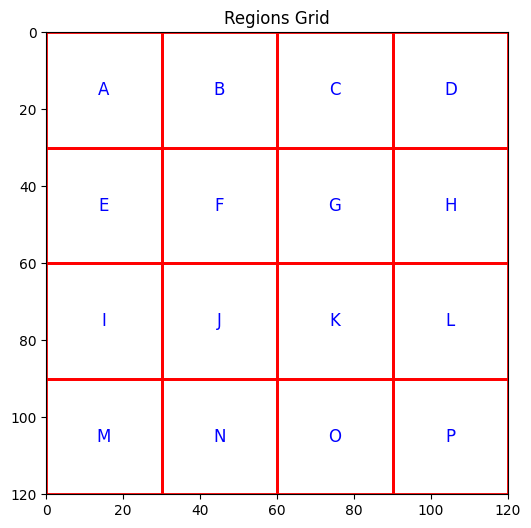

In [3]:
regions = {
    # First Row
    "A": (0, 0, IMG_WIDTH/4 , IMG_HEIGHT/4),
    "B": (IMG_WIDTH/4, 0, IMG_WIDTH/2, IMG_HEIGHT/4),
    "C": (IMG_WIDTH/2, 0, 3*IMG_WIDTH/4, IMG_HEIGHT/4),
    "D": (3*IMG_WIDTH/4, 0, IMG_WIDTH, IMG_HEIGHT/4),
    # Second Row
    "E": (0, IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT/2),
    "F": (IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT/2),
    "G": (IMG_WIDTH/2, IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT/2),
    "H": (3*IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT/2),
    # Third Row
    "I": (0, IMG_HEIGHT/2, IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "J": (IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH/2, 3*IMG_HEIGHT/4),
    "K": (IMG_WIDTH/2, IMG_HEIGHT/2, 3*IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "L": (3*IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH, 3*IMG_HEIGHT/4),
    # Fourth Row
    "M": (0, 3*IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT),
    "N": (IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT),
    "O": (IMG_WIDTH/2, 3*IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT),
    "P": (3*IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT),
}

fig, ax = plt.subplots(figsize=(6,6))

for label, (x1, y1, x2, y2) in regions.items():
    w = x2 - x1
    h = y2 - y1
    rect = patches.Rectangle((x1, y1), w, h, 
                             fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)
    ax.text(x1 + w/2, y1 + h/2, label, 
            ha='center', va='center', fontsize=12,
            color='blue')

ax.set_xlim([0, IMG_WIDTH])
ax.set_ylim([0, IMG_HEIGHT])
ax.set_aspect('equal')
ax.invert_yaxis()
plt.title("Regions Grid")
plt.show()

In [4]:
# Define the transformations
transformx = ACompose([
    AHorizontalFlip(p=0.5),
    AVerticalFlip(p=0.5),
],is_check_shapes=False)

# Parquet file with metadata for Big Earth dataset
train_matches, val_matches, test_matches = match_keys(parquet_path)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

random.seed(42)
train_matches_subsample = random.sample(train_matches, len(train_matches)//10)

subsample_image_keys = []
subsample_mask_keys = []
# for match in old_train_matches:
for match in train_matches_subsample:
    train_image_key, train_mask_key = match
    subsample_image_keys.append(train_image_key)
    subsample_mask_keys.append(train_mask_key)

print(train_matches_subsample[:5])


Train size: 237871, Val size: 122342, Test size: 119825
[('S1A_IW_GRDH_1SDV_20180126T161302_34VDN_15_88', 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN_15_88_reference_map'), ('S1A_IW_GRDH_1SDV_20170903T153258_35VNL_70_4', 'S2A_MSIL2A_20170905T095031_N9999_R079_T35VNL_70_04_reference_map'), ('S1A_IW_GRDH_1SDV_20170617T064659_29UPU_62_3', 'S2A_MSIL2A_20170617T113321_N9999_R080_T29UPU_62_03_reference_map'), ('S1A_IW_GRDH_1SDV_20180420T063917_29UPU_27_80', 'S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_27_80_reference_map'), ('S1A_IW_GRDH_1SDV_20180413T161957_34UEG_40_3', 'S2A_MSIL2A_20180413T095031_N9999_R079_T34UEG_40_03_reference_map')]


## Calculate and Store in CSV

In [13]:
# Load the model
model = load_from_checkpoint_skipconn("../models/unet120_full_skipconn_best.pth")  # Modify this with your actual model loading function
model.eval();
model.to(device)

random.seed(42)
num = 1000
random_regions = random.choices(list(regions.values()), k=num)
random_references = random.sample(test_matches, num)
random_test_imgs, random_test_masks = [], []

print(f"Random references: {random_references}")
for image_reference, mask_reference in random_references:
    test_img, test_mask = get_image_and_mask_from_key(image_reference, lmdb_path = dataset_lmdb_path)
    random_test_imgs.append(test_img)
    random_test_masks.append(test_mask)

start_index = 120
end_index = 130

print(random_references[start_index:end_index])
print(random_regions[start_index:end_index])
print(len(random_test_imgs[start_index:end_index]))

layer_names = ["encoder.layer3", "encoder.layer4", "decoder.up1", "decoder.up2"]

CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)
Random references: [('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42', 'S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK_44_42_reference_map'), ('S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37', 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_33_37_reference_map'), ('S1B_IW_GRDH_1SDV_20171220T050937_33TWN_63_66', 'S2B_MSIL2A_20171219T095409_N9999_R079_T33TWN_63_66_reference_map'), ('S1A_IW_GRDH_1SDV_20180509T160543_34VDR_64_67', 'S2A_MSIL2A_20180509T101031_N9999_R022_T34VDR_64_67_reference_map'), ('S1A_IW_GRDH_1SDV_20170706T064300_29SND_42_61', 'S2A_MSIL2A_20170704T112111_N

In [ ]:
top_ns = [find_n_similar_images(
                            img,
                            layer_names,
                            subsample_image_keys[:],
                            prototype_lmdb_path,
                            dataset_lmdb_path,
                            model,
                            img_hw=IMG_SIZE,
                            region_coords=random_regions[i+start_index],
                            plotting = False) 
                            for i,img in enumerate(random_test_imgs[start_index:end_index])]

print(top_ns)  #[image_1[layer1[results] ...]]

f:\Thesis\.conda\lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [11]:
if os.path.exists("top_matches_skipp_conn.csv"):
    data_matches = pd.read_csv("top_matches_skipp_conn.csv").to_dict(orient='records')
else:
    data_matches = []

# Add to dataframe
for img_index, image_result in enumerate(top_ns):
    for top_n, layer_name in zip(image_result, layer_names):
        # Check if the image already exists in the DataFrame
        exists = any(d["image_id"] == random_references[img_index + start_index][0] and d["layer"] == layer_name for d in data_matches)
        if exists:
            print(f"Image {random_references[img_index + start_index][0]} with layer {layer_name} already exists in the DataFrame.")
        else:
            data_matches.append({
                "image_id" : random_references[img_index + start_index][0],  # Image reference
                "original_region" : random_regions[img_index + start_index],  # Region coordinates
                "layer": layer_name,
                "top_n": top_n,
            })

df_top_matches = pd.DataFrame(data_matches)

# Save the DataFrame to a CSV file
df_top_matches.to_csv("top_matches_skipp_conn.csv", index=False)

# df_top_matches = pd.read_csv("top_matchesx.csv")
# unique_image_ids = ["S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55"]

## Trial with a single Image

F:\Thesis\ActivationPrototypes_SARSeg\ActivationPrototypes_SARSeg\thesis_utils.py:1182: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  activation_tensor = torch.from_numpy(activation_array).reshape(LAYER_SHAPES[layer_name])


   Results for layer: encoder.layer3
   Top N Results: [(0.7926725149154663, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_11_78', (60, 30, 90, 60)), (0.7776575088500977, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_28_85', (60, 60, 90, 90)), (0.7716956734657288, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_28_85', (30, 30, 60, 60)), (0.7698257565498352, 'S1A_IW_GRDH_1SDV_20170812T182712_29SNC_11_1', (0, 60, 30, 90)), (0.7530215978622437, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_11_78', (30, 30, 60, 60)), (0.7525678873062134, 'S1A_IW_GRDH_1SDV_20171004T183450_29SNC_34_90', (30, 90, 60, 120)), (0.7471936941146851, 'S1A_IW_GRDH_1SDV_20180421T165046_33TWN_70_8', (30, 60, 60, 90)), (0.7443395853042603, 'S1B_IW_GRDH_1SDV_20180515T063421_29SNC_80_82', (30, 60, 60, 90)), (0.7423760294914246, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_11_78', (60, 0, 90, 30)), (0.7415066361427307, 'S1A_IW_GRDH_1SDV_20170808T043524_35ULA_17_88', (30, 60, 60, 90)), (0.7376312613487244, 'S1A_IW_GRDH_1SDV_20171203T183450_29SNB_34_4',

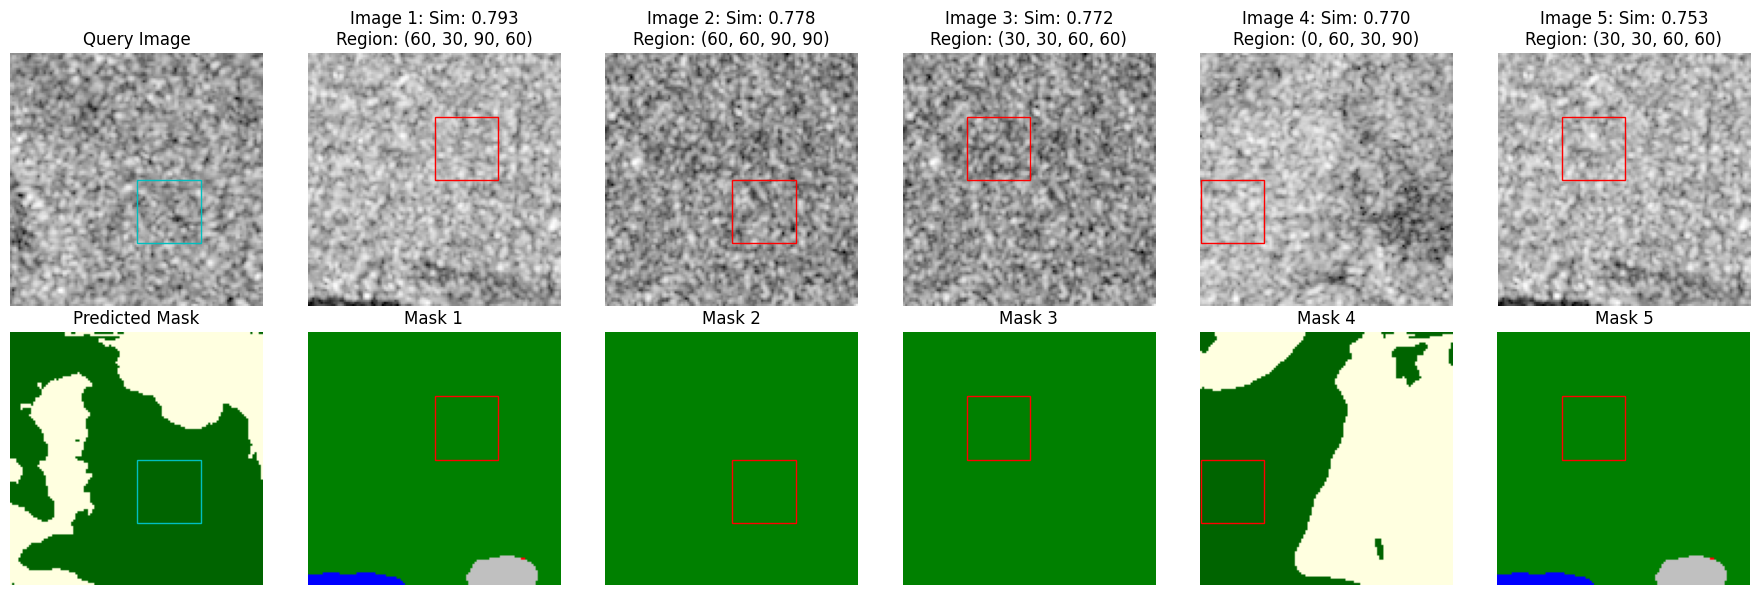

   Results for layer: encoder.layer4
   Top N Results: [(0.8581828474998474, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (60, 60, 90, 90)), (0.8533517718315125, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (30, 60, 60, 90)), (0.8387961387634277, 'S1A_IW_GRDH_1SDV_20170812T182712_29SNC_11_1', (30, 60, 60, 90)), (0.8242343664169312, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (30, 60, 60, 90)), (0.8226029872894287, 'S1A_IW_GRDH_1SDV_20180327T064301_29SNB_31_5', (60, 60, 90, 90)), (0.8197301626205444, 'S1B_IW_GRDH_1SDV_20180515T063421_29SNC_80_82', (30, 60, 60, 90)), (0.8184577822685242, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (60, 60, 90, 90)), (0.8153573274612427, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (30, 30, 60, 60)), (0.814599871635437, 'S1A_IW_GRDH_1SDV_20170812T182712_29SNC_14_4', (60, 60, 90, 90)), (0.8145629167556763, 'S1A_IW_GRDH_1SDV_20180327T064301_29SNB_31_5', (60, 30, 90, 60)), (0.8082613945007324, 'S1A_IW_GRDH_1SDV_20171004T183515_29SNC_20_5', (60

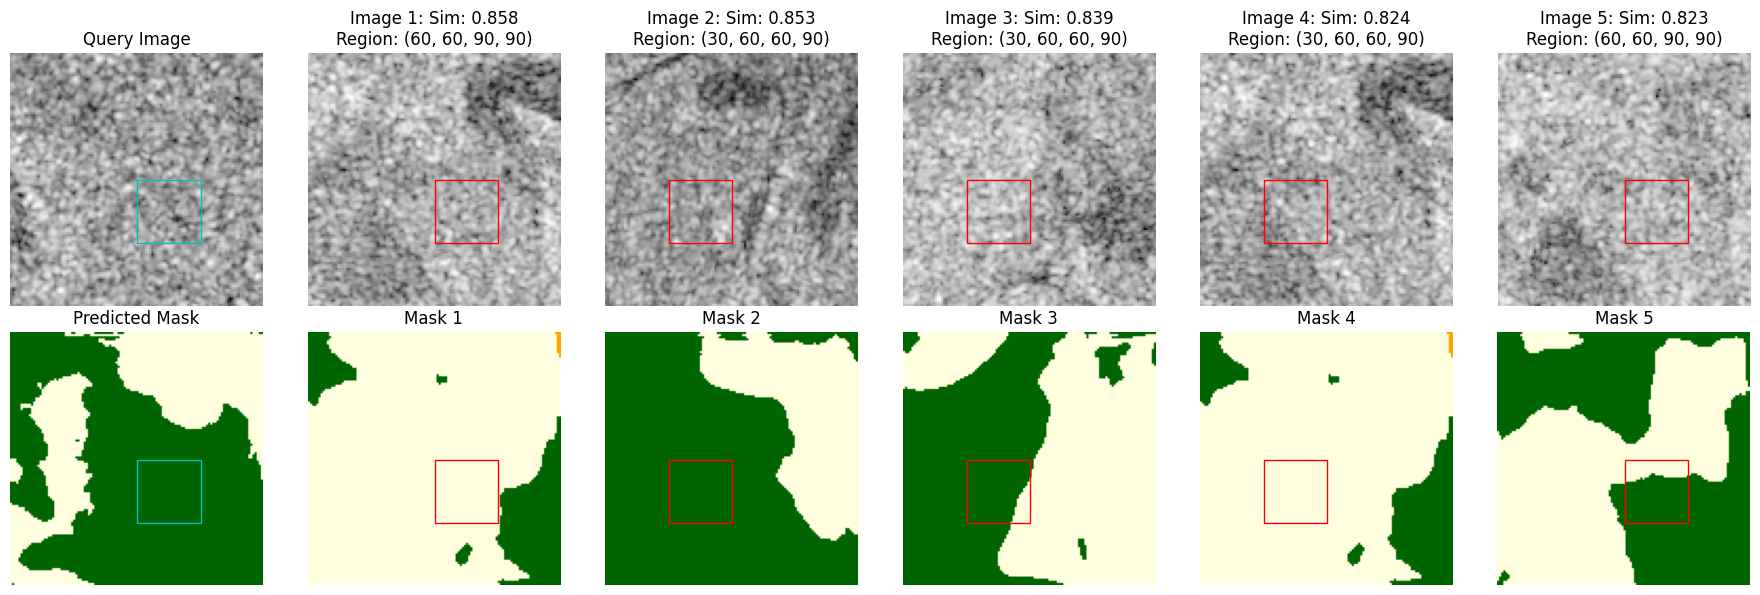

   Results for layer: decoder.up1
   Top N Results: [(0.905468225479126, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (60, 60, 90, 90)), (0.8884643912315369, 'S1A_IW_GRDH_1SDV_20180327T064301_29SNB_31_5', (60, 60, 90, 90)), (0.8779300451278687, 'S1A_IW_GRDH_1SDV_20180327T064301_29SNB_31_5', (60, 30, 90, 60)), (0.8749608397483826, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (30, 60, 60, 90)), (0.8646763563156128, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (60, 30, 90, 60)), (0.8548292517662048, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (30, 30, 60, 60)), (0.8500726222991943, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (60, 60, 90, 90)), (0.8464159965515137, 'S1A_IW_GRDH_1SDV_20170812T182712_29SNC_23_5', (60, 60, 90, 90)), (0.8409250974655151, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (90, 60, 120, 90)), (0.8405741453170776, 'S1B_IW_GRDH_1SDV_20180515T063421_29SNC_12_77', (60, 30, 90, 60)), (0.840430498123169, 'S1B_IW_GRDH_1SDV_20171203T064230_29SNB_31_5', (60, 90,

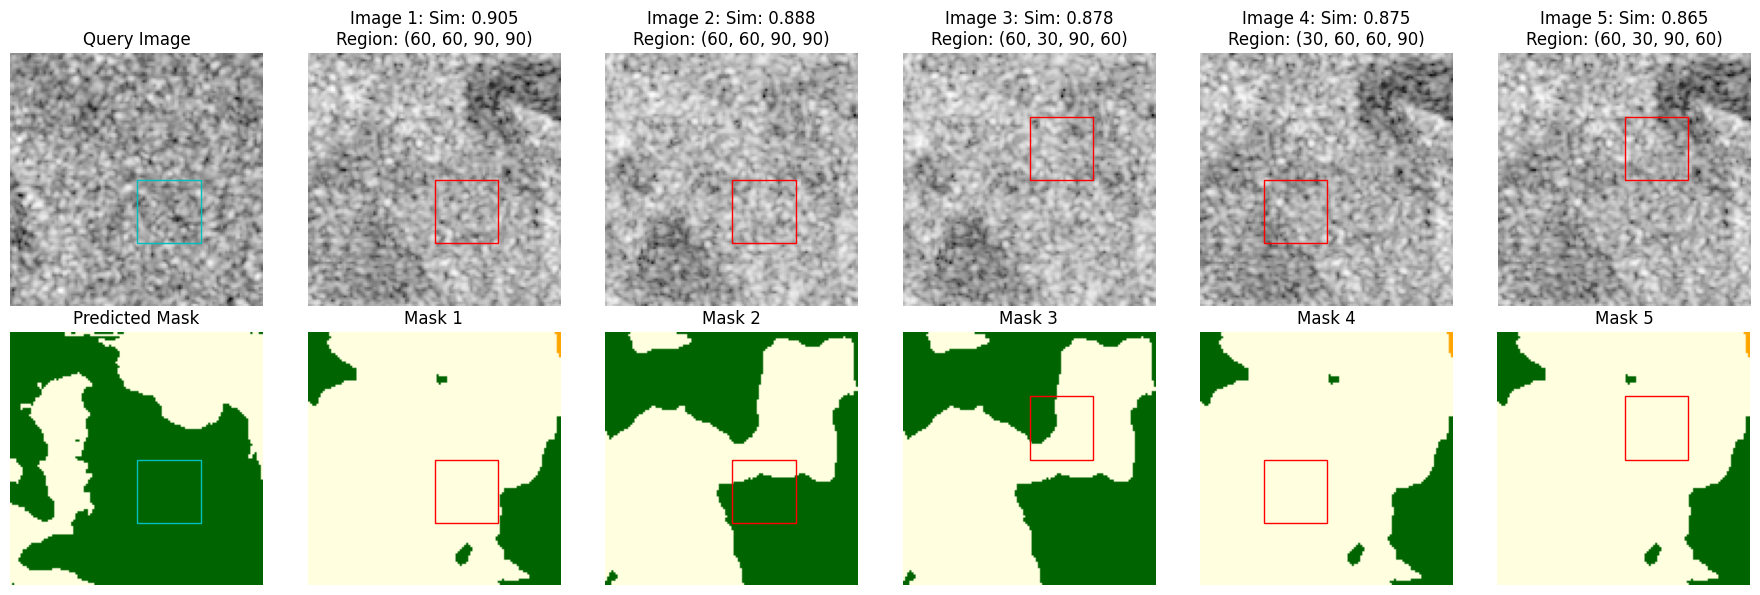

   Results for layer: decoder.up2
   Top N Results: [(0.8934857845306396, 'S1B_IW_GRDH_1SDV_20180515T063356_29SND_0_52', (32, 64, 64, 96)), (0.8926738500595093, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (32, 64, 64, 96)), (0.8910274505615234, 'S1B_IW_GRDH_1SDV_20180515T063356_29SND_0_52', (64, 64, 96, 96)), (0.8869312405586243, 'S1B_IW_GRDH_1SDV_20180515T063356_29SND_0_52', (32, 32, 64, 64)), (0.8762680292129517, 'S1A_IW_GRDH_1SDV_20170812T182712_29SNC_11_1', (0, 64, 32, 96)), (0.871672511100769, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (32, 32, 64, 64)), (0.8700231313705444, 'S1A_IW_GRDH_1SDV_20171004T183515_29SNC_26_0', (32, 32, 64, 64)), (0.8692370653152466, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (0, 64, 32, 96)), (0.868925929069519, 'S1B_IW_GRDH_1SDV_20170701T182622_29SND_85_23', (0, 32, 32, 64)), (0.8688071966171265, 'S1A_IW_GRDH_1SDV_20171004T183450_29SNB_39_7', (32, 32, 64, 64)), (0.8684158325195312, 'S1A_IW_GRDH_1SDV_20171004T183450_29SNB_39_7', (32, 0, 64

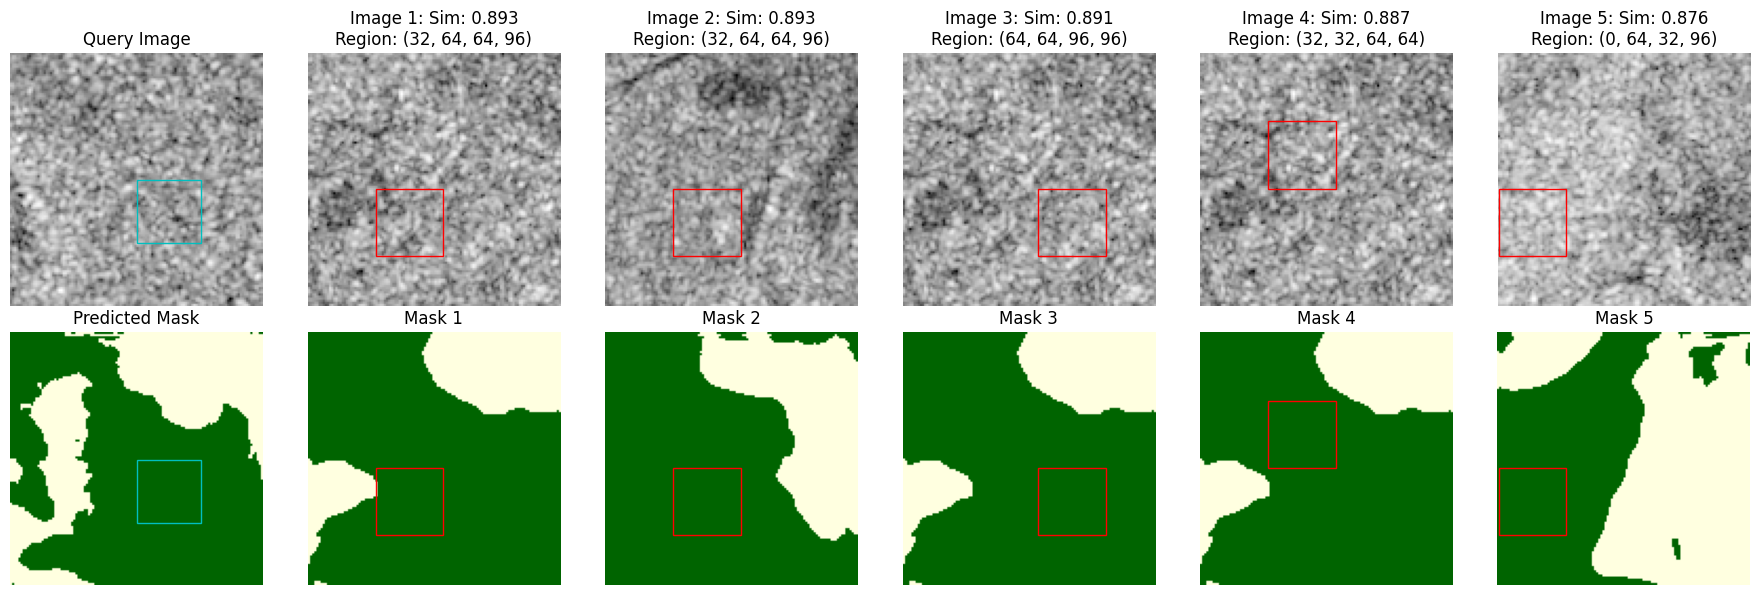

In [14]:
layer_names = ["encoder.layer3", "encoder.layer4", "decoder.up1", "decoder.up2"]
test_top_n = find_n_similar_images(
                            random_test_imgs[0],
                            layer_names,
                            subsample_image_keys[:],
                            prototype_lmdb_path,
                            dataset_lmdb_path,
                            model,
                            img_hw=IMG_SIZE,
                            region_coords=random_regions[0],
                            plotting = True)

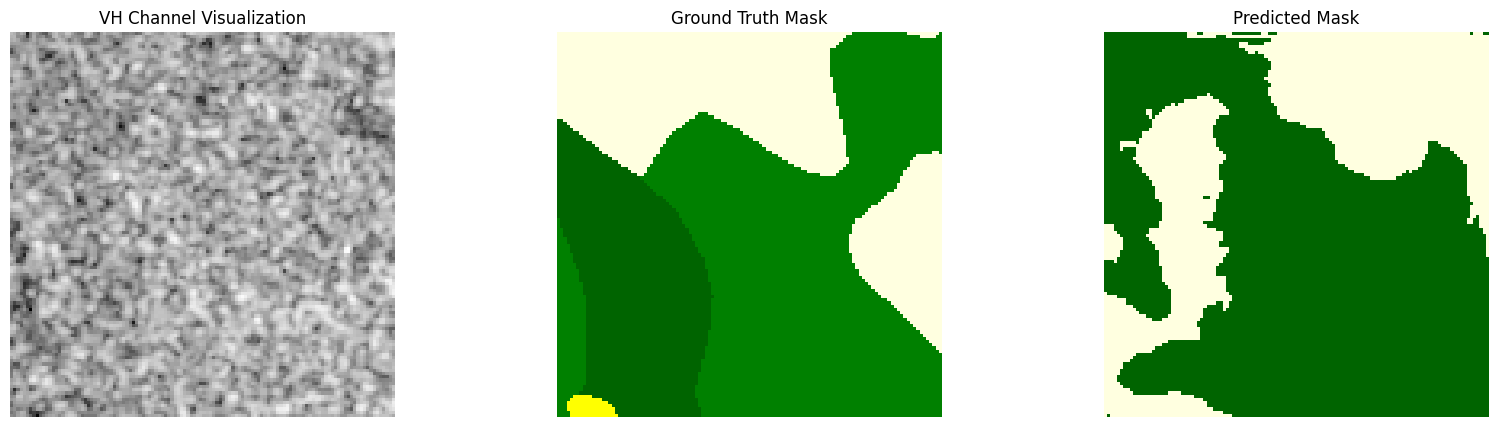

In [13]:
img_ref, mask_ref = random_references[0]
display_good_bad(model,
                 dataset_lmdb_path,
                 img_ref,
                 mask_ref,
                 img_size= 120)
